In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("PyTorch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [3]:
ruta = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab03/AmesHousing.csv'

data = pd.read_csv(ruta)

data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
features = [
    'MS SubClass',
    'Lot Frontage',
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'Mas Vnr Area',
    'Total Bsmt SF',
    '1st Flr SF',
    '2nd Flr SF',
    'Gr Liv Area',
    'Bsmt Full Bath',
    'Full Bath',
    'Half Bath',
    'Bedroom AbvGr',
    'TotRms AbvGrd',
    'Fireplaces',
    'Garage Cars',
    'Garage Area'
]

target = 'SalePrice'

print("Cantidad de características:", len(features))

Cantidad de características: 20


In [5]:
X_df = data[features].copy()

y_df = data[[target]].copy()

print("X:", X_df.shape)
print("y:", y_df.shape)

X: (2930, 20)
y: (2930, 1)


In [6]:
X_train_df, X_val_df, y_train_df, y_val_df = train_test_split(
    X_df,
    y_df,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train_df.shape)
print("Validación:", X_val_df.shape)

Train: (2344, 20)
Validación: (586, 20)


In [7]:
medias = X_train_df.mean()

X_train_df = X_train_df.fillna(
    medias
)

X_val_df = X_val_df.fillna(
    medias
)

print(
    "Nulos train:",
    X_train_df.isnull().sum().sum()
)

print(
    "Nulos val:",
    X_val_df.isnull().sum().sum()
)

Nulos train: 0
Nulos val: 0


In [8]:
X_train = X_train_df.values.astype(
    np.float32
)

X_val = X_val_df.values.astype(
    np.float32
)

y_train = y_train_df.values.astype(
    np.float32
)

y_val = y_val_df.values.astype(
    np.float32
)

print(X_train.shape)
print(y_train.shape)

(2344, 20)
(2344, 1)


In [9]:
mu = X_train.mean(
    axis=0
)

sigma = X_train.std(
    axis=0
)

sigma[sigma == 0] = 1

X_train_norm = (
    X_train - mu
) / sigma

X_val_norm = (
    X_val - mu
) / sigma

print("Normalización completada")

Normalización completada


In [10]:
class DatasetPersonalizado(
    torch.utils.data.Dataset
):

    def __init__(self, X, Y):

        self.X = torch.from_numpy(
            X
        ).float()

        self.Y = torch.from_numpy(
            Y
        ).float()


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        return (
            self.X[ix],
            self.Y[ix]
        )

In [11]:
dataset_lineal = {

    'train': DatasetPersonalizado(
        X_train_norm,
        y_train
    ),

    'val': DatasetPersonalizado(
        X_val_norm,
        y_val
    )
}

print(
    "Train:",
    len(dataset_lineal['train'])
)

print(
    "Val:",
    len(dataset_lineal['val'])
)

Train: 2344
Val: 586


In [12]:
dataloader_lineal = {

    'train': torch.utils.data.DataLoader(
        dataset_lineal['train'],
        batch_size=64,
        shuffle=True
    ),

    'val': torch.utils.data.DataLoader(
        dataset_lineal['val'],
        batch_size=64,
        shuffle=False
    )
}

In [13]:
x_b, y_b = next(
    iter(
        dataloader_lineal['train']
    )
)

print(
    "X:",
    x_b.shape
)

print(
    "y:",
    y_b.shape
)

X: torch.Size([64, 20])
y: torch.Size([64, 1])


In [14]:
class ModeloLinealMultiple(
    torch.nn.Module
):

    def __init__(self):

        super(
            ModeloLinealMultiple,
            self
        ).__init__()

        self.linear = torch.nn.Linear(
            20,
            1
        )


    def forward(self, x):

        return self.linear(x)

In [15]:
model_lineal = ModeloLinealMultiple().to(
    device
)

criterion_lineal = torch.nn.MSELoss()

optimizer_lineal = torch.optim.SGD(
    model_lineal.parameters(),
    lr=0.001
)

print(model_lineal)

ModeloLinealMultiple(
  (linear): Linear(in_features=20, out_features=1, bias=True)
)


In [16]:
def fit(
    model,
    dataloader,
    optimizer,
    nombre_modelo,
    epochs=500,
    log_each=50
):

    criterion = torch.nn.MSELoss()

    train_loss = []
    val_loss = []

    best_loss = float('inf')


    for e in range(
        1,
        epochs + 1
    ):

        model.train()

        _train_loss = []


        for x_b, y_b in dataloader['train']:

            x_b = x_b.to(device)
            y_b = y_b.to(device)

            y_pred = model(x_b)

            loss = criterion(
                y_pred,
                y_b
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            _train_loss.append(
                loss.item()
            )


        train_loss.append(
            np.mean(_train_loss)
        )


        model.eval()

        _val_loss = []


        with torch.no_grad():

            for x_b, y_b in dataloader['val']:

                x_b = x_b.to(device)
                y_b = y_b.to(device)

                y_pred = model(x_b)

                loss = criterion(
                    y_pred,
                    y_b
                )

                _val_loss.append(
                    loss.item()
                )


        val_loss.append(
            np.mean(_val_loss)
        )


        if val_loss[-1] < best_loss:

            best_loss = val_loss[-1]

            torch.save(
                model.state_dict(),
                nombre_modelo
            )


        if not e % log_each:

            print(
                f"Epoch {e}/{epochs} "
                f"loss {train_loss[-1]:.2f} "
                f"val_loss {val_loss[-1]:.2f}"
            )


    model.load_state_dict(
        torch.load(
            nombre_modelo,
            map_location=device
        )
    )


    return {
        'epoch':
            list(
                range(
                    1,
                    len(train_loss) + 1
                )
            ),

        'loss':
            train_loss,

        'val_loss':
            val_loss
    }

In [17]:
model_lineal = ModeloLinealMultiple().to(
    device
)

optimizer_lineal = torch.optim.SGD(
    model_lineal.parameters(),
    lr=0.001
)

hist_lineal = fit(
    model_lineal,
    dataloader_lineal,
    optimizer_lineal,
    'mejor_modelo_lineal_lab03.pt',
    epochs=500,
    log_each=50
)

Epoch 50/500 loss 1119491865.08 val_loss 1492029017.60
Epoch 100/500 loss 1069567851.24 val_loss 1448688915.20
Epoch 150/500 loss 1059278231.35 val_loss 1453137120.00
Epoch 200/500 loss 1064350549.62 val_loss 1459848979.20
Epoch 250/500 loss 1061629049.08 val_loss 1466721356.80
Epoch 300/500 loss 1063547605.62 val_loss 1470369536.00
Epoch 350/500 loss 1058974915.46 val_loss 1467064608.00
Epoch 400/500 loss 1063404421.19 val_loss 1468391545.60
Epoch 450/500 loss 1061929109.62 val_loss 1471521459.20
Epoch 500/500 loss 1057723451.68 val_loss 1470056768.00


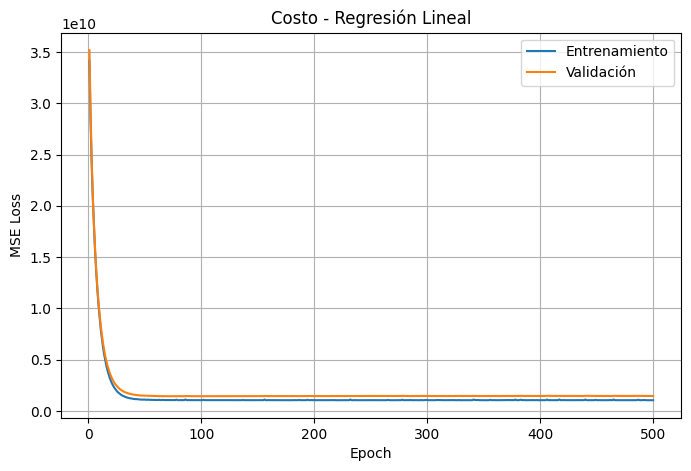

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist_lineal['epoch'],
    hist_lineal['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist_lineal['epoch'],
    hist_lineal['val_loss'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Costo - Regresión Lineal')

plt.legend()
plt.grid()
plt.show()

In [19]:
model_lineal.eval()

pred_lineal = []
real_lineal = []

with torch.no_grad():

    for x_b, y_b in dataloader_lineal['val']:

        x_b = x_b.to(device)

        pred = model_lineal(x_b)

        pred_lineal.extend(
            pred.cpu().numpy()
        )

        real_lineal.extend(
            y_b.numpy()
        )

pred_lineal = np.array(
    pred_lineal
).flatten()

real_lineal = np.array(
    real_lineal
).flatten()

In [20]:
mse_lineal = mean_squared_error(
    real_lineal,
    pred_lineal
)

rmse_lineal = np.sqrt(
    mse_lineal
)

mae_lineal = mean_absolute_error(
    real_lineal,
    pred_lineal
)

r2_lineal = r2_score(
    real_lineal,
    pred_lineal
)

print("MODELO LINEAL")

print("MSE :", mse_lineal)
print("RMSE:", rmse_lineal)
print("MAE :", mae_lineal)
print("R²  :", r2_lineal)

MODELO LINEAL
MSE : 1324648448.0
RMSE: 36395.72018795617
MAE : 22264.57421875
R²  : 0.8347813487052917


In [21]:
X_train_poly = np.concatenate(
    [
        X_train,
        X_train ** 2
    ],
    axis=1
)

X_val_poly = np.concatenate(
    [
        X_val,
        X_val ** 2
    ],
    axis=1
)

print(
    "Train polinómico:",
    X_train_poly.shape
)

print(
    "Val polinómico:",
    X_val_poly.shape
)

Train polinómico: (2344, 40)
Val polinómico: (586, 40)


In [22]:
mu_poly = X_train_poly.mean(
    axis=0
)

sigma_poly = X_train_poly.std(
    axis=0
)

sigma_poly[
    sigma_poly == 0
] = 1

X_train_poly_norm = (
    X_train_poly - mu_poly
) / sigma_poly

X_val_poly_norm = (
    X_val_poly - mu_poly
) / sigma_poly

print(
    "Normalización polinómica completada"
)

Normalización polinómica completada


In [23]:
dataset_poly = {

    'train': DatasetPersonalizado(
        X_train_poly_norm,
        y_train
    ),

    'val': DatasetPersonalizado(
        X_val_poly_norm,
        y_val
    )
}

print(
    "Train:",
    len(dataset_poly['train'])
)

print(
    "Val:",
    len(dataset_poly['val'])
)

Train: 2344
Val: 586


In [24]:
dataloader_poly = {

    'train': torch.utils.data.DataLoader(
        dataset_poly['train'],
        batch_size=64,
        shuffle=True
    ),

    'val': torch.utils.data.DataLoader(
        dataset_poly['val'],
        batch_size=64,
        shuffle=False
    )
}

In [25]:
x_b, y_b = next(
    iter(
        dataloader_poly['train']
    )
)

print(
    "X:",
    x_b.shape
)

print(
    "y:",
    y_b.shape
)

X: torch.Size([64, 40])
y: torch.Size([64, 1])


In [26]:
class ModeloPolinomico(
    torch.nn.Module
):

    def __init__(self):

        super(
            ModeloPolinomico,
            self
        ).__init__()

        self.linear = torch.nn.Linear(
            40,
            1
        )


    def forward(self, x):

        return self.linear(x)

In [27]:
model_poly = ModeloPolinomico().to(
    device
)

optimizer_poly = torch.optim.SGD(
    model_poly.parameters(),
    lr=0.001
)

hist_poly = fit(
    model_poly,
    dataloader_poly,
    optimizer_poly,
    'mejor_modelo_poly_lab03.pt',
    epochs=500,
    log_each=50
)

Epoch 50/500 loss 929432700.54 val_loss 1451117292.80
Epoch 100/500 loss 847921568.00 val_loss 1392147680.00
Epoch 150/500 loss 824318466.59 val_loss 1365767708.80
Epoch 200/500 loss 806826931.89 val_loss 1364736028.80
Epoch 250/500 loss 792579667.03 val_loss 1354140732.80
Epoch 300/500 loss 795153418.38 val_loss 1342750419.20
Epoch 350/500 loss 775609171.03 val_loss 1339966972.80
Epoch 400/500 loss 778524802.59 val_loss 1321687126.40
Epoch 450/500 loss 763064320.00 val_loss 1321556716.80
Epoch 500/500 loss 772770783.14 val_loss 1314952211.20


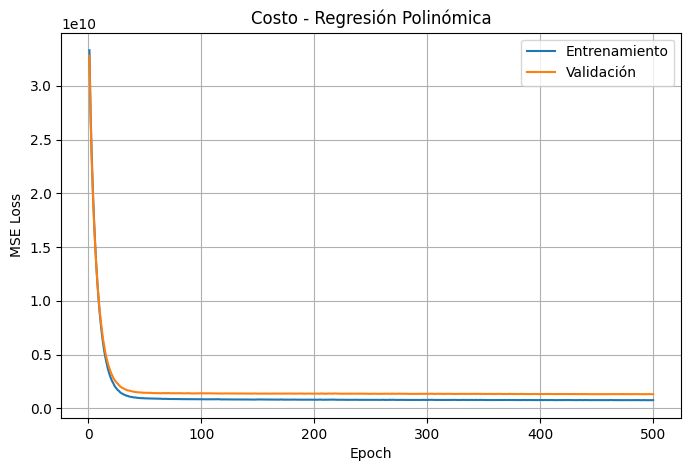

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist_poly['epoch'],
    hist_poly['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist_poly['epoch'],
    hist_poly['val_loss'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Costo - Regresión Polinómica')

plt.legend()
plt.grid()
plt.show()

In [29]:
model_poly.eval()

pred_poly = []
real_poly = []

with torch.no_grad():

    for x_b, y_b in dataloader_poly['val']:

        x_b = x_b.to(device)

        pred = model_poly(x_b)

        pred_poly.extend(
            pred.cpu().numpy()
        )

        real_poly.extend(
            y_b.numpy()
        )

pred_poly = np.array(pred_poly).flatten()
real_poly = np.array(real_poly).flatten()

In [30]:
mse_poly = mean_squared_error(
    real_poly,
    pred_poly
)

rmse_poly = np.sqrt(
    mse_poly
)

mae_poly = mean_absolute_error(
    real_poly,
    pred_poly
)

r2_poly = r2_score(
    real_poly,
    pred_poly
)

print("MODELO POLINÓMICO")

print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("MAE :", mae_poly)
print("R²  :", r2_poly)

MODELO POLINÓMICO
MSE : 1227058560.0
RMSE: 35029.39565564899
MAE : 20963.396484375
R²  : 0.8469533920288086


In [31]:
X_train_normal_t = torch.tensor(
    X_train_norm,
    dtype=torch.float32,
    device=device
)

X_val_normal_t = torch.tensor(
    X_val_norm,
    dtype=torch.float32,
    device=device
)

y_train_normal_t = torch.tensor(
    y_train,
    dtype=torch.float32,
    device=device
)

y_val_normal_t = torch.tensor(
    y_val,
    dtype=torch.float32,
    device=device
)

In [32]:
unos_train = torch.ones(
    (X_train_normal_t.shape[0], 1),
    device=device
)

unos_val = torch.ones(
    (X_val_normal_t.shape[0], 1),
    device=device
)

X_train_aug = torch.cat(
    [unos_train, X_train_normal_t],
    dim=1
)

X_val_aug = torch.cat(
    [unos_val, X_val_normal_t],
    dim=1
)

print("Train:", X_train_aug.shape)
print("Val:", X_val_aug.shape)

Train: torch.Size([2344, 21])
Val: torch.Size([586, 21])


In [33]:
theta_normal = (
    torch.linalg.pinv(X_train_aug)
    @ y_train_normal_t
)

print(
    "Theta:",
    theta_normal.shape
)

Theta: torch.Size([21, 1])


In [34]:
with torch.no_grad():

    pred_normal_t = (
        X_val_aug
        @ theta_normal
    )

pred_normal = (
    pred_normal_t
    .cpu()
    .numpy()
    .flatten()
)

real_normal = (
    y_val_normal_t
    .cpu()
    .numpy()
    .flatten()
)

In [35]:
mse_normal = mean_squared_error(
    real_normal,
    pred_normal
)

rmse_normal = np.sqrt(
    mse_normal
)

mae_normal = mean_absolute_error(
    real_normal,
    pred_normal
)

r2_normal = r2_score(
    real_normal,
    pred_normal
)

print("ECUACIÓN NORMAL")

print("MSE :", mse_normal)
print("RMSE:", rmse_normal)
print("MAE :", mae_normal)
print("R²  :", r2_normal)

ECUACIÓN NORMAL
MSE : 1355862144.0
RMSE: 36822.033403928144
MAE : 22476.720703125
R²  : 0.8308881521224976


In [36]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Lineal',
        'Polinómico',
        'Ecuación Normal'
    ],

    'MSE': [
        mse_lineal,
        mse_poly,
        mse_normal
    ],

    'RMSE': [
        rmse_lineal,
        rmse_poly,
        rmse_normal
    ],

    'MAE': [
        mae_lineal,
        mae_poly,
        mae_normal
    ],

    'R2': [
        r2_lineal,
        r2_poly,
        r2_normal
    ]
})

comparacion

,Modelo,MSE,RMSE,MAE,R2
0,Lineal,1.324648e+09,36395.720188,22264.574219,0.834781
1,Polinómico,1.227059e+09,35029.395656,20963.396484,0.846953
2,Ecuación Normal,1.355862e+09,36822.033404,22476.720703,0.830888


In [37]:
resultados_100 = pd.DataFrame({

    'Real': real_lineal[:100],

    'Lineal': pred_lineal[:100],

    'Polinomico': pred_poly[:100],

    'Ecuacion_Normal': pred_normal[:100]
})

resultados_100

,Real,Lineal,Polinomico,Ecuacion_Normal
0,161000.0,185686.281250,189606.781250,192259.531250
1,116000.0,116706.343750,101102.375000,116247.468750
2,196500.0,220560.812500,207829.000000,219623.984375
3,123600.0,105305.296875,132105.593750,109307.218750
4,126000.0,142557.203125,140900.015625,142565.984375
...,...,...,...,...
95,177439.0,191499.031250,180405.625000,190884.375000
96,44000.0,10363.515625,30448.187500,8743.898438
97,245000.0,233571.062500,235145.125000,237045.968750
98,215700.0,208322.140625,201736.015625,210742.125000


In [38]:
carpeta = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'LabPyTorch/'
    'Lab03'
)

os.makedirs(
    carpeta,
    exist_ok=True
)

PATH = os.path.join(
    carpeta,
    'lab03_checkpoint.pt'
)

torch.save(
    {
        'modelo_lineal':
            model_lineal.state_dict(),

        'modelo_polinomico':
            model_poly.state_dict(),

        'theta_normal':
            theta_normal.cpu(),

        'mu':
            mu,

        'sigma':
            sigma,

        'mu_poly':
            mu_poly,

        'sigma_poly':
            sigma_poly,

        'medias_nulos':
            medias.values,

        'metricas_lineal': {
            'mse': mse_lineal,
            'rmse': rmse_lineal,
            'mae': mae_lineal,
            'r2': r2_lineal
        },

        'metricas_poly': {
            'mse': mse_poly,
            'rmse': rmse_poly,
            'mae': mae_poly,
            'r2': r2_poly
        },

        'metricas_normal': {
            'mse': mse_normal,
            'rmse': rmse_normal,
            'mae': mae_normal,
            'r2': r2_normal
        }
    },

    PATH
)

print("Guardado en:")
print(PATH)

Guardado en:
/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch/Lab03/lab03_checkpoint.pt


In [39]:
print(
    "Existe:",
    os.path.exists(PATH)
)

Existe: True


In [40]:
checkpoint = torch.load(
    PATH,
    map_location=device,
    weights_only=False
)

print(
    "Checkpoint Lab03 cargado"
)

Checkpoint Lab03 cargado


In [41]:
print(
    "LABORATORIO 03 PYTORCH COMPLETADO"
)

print(
    "Dataset          : Ames Housing"
)

print(
    "Objetivo         : SalePrice"
)

print(
    "Características  : 20"
)

print(
    "Modelo lineal    : OK"
)

print(
    "Modelo polinómico: OK"
)

print(
    "Ecuación normal  : OK"
)

print(
    "Dataset/DataLoader: OK"
)

print(
    "Métricas         : OK"
)

print(
    "100 predicciones : OK"
)

print(
    "Checkpoint       : OK"
)

LABORATORIO 03 PYTORCH COMPLETADO
Dataset          : Ames Housing
Objetivo         : SalePrice
Características  : 20
Modelo lineal    : OK
Modelo polinómico: OK
Ecuación normal  : OK
Dataset/DataLoader: OK
Métricas         : OK
100 predicciones : OK
Checkpoint       : OK
